# Add Linear Trend

`add_linear_trend` superimposes a linear ramp whose energy is matched to the
series, then scaled by `trend_strength`. `direction` is `"upward"` or
`"downward"`. With `normalize=True` (default) the result is affine-rescaled to
the original mean and std, so the trend is visible as a **tilt** rather than a
change in overall scale. With `normalize=False` the series and trend are averaged.

| Parameter | Default | Role |
| --- | --- | --- |
| `trend_strength` | 1.0 | Multiplier on the energy-matched ramp |
| `direction` | `"upward"` | Sign of the slope |
| `normalize` | True | Restore original mean / std after adding the trend |


In [1]:
%matplotlib inline
import os
import sys

import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath(os.path.join("..", "..")))

from s2generator.utils import (
    load_univariate,
    generate_arma_samples,
    generate_nonstationary_sine,
    generate_chirp_signal,
)

L = 512
rng = np.random.RandomState(0)
np.random.seed(0)

synth = np.asarray(generate_arma_samples(L), dtype=float)
real = load_univariate("ETTh1")[:L].astype(float)


def overlay_pair(originals, variants, titles, ylabel="value"):
    # Plot original vs augmented traces for synth (left) and real (right).
    n = len(titles)
    fig, axes = plt.subplots(
        n, 2, figsize=(11.5, 2.55 * n), sharex=False, squeeze=False
    )
    col_titles = ["synthetic (ARMA)", "real (ETTh1 OT)"]
    for col, (orig, var_list) in enumerate(zip(originals, variants)):
        for row, (label, series) in enumerate(var_list):
            ax = axes[row, col]
            ax.plot(orig, color="0.55", lw=1.15, label="original")
            ax.plot(series, color="C0", lw=1.15, alpha=0.9, label=label)
            if row == 0:
                ax.set_title(col_titles[col], fontweight="bold")
            if col == 0:
                ax.set_ylabel(ylabel)
            ax.legend(fontsize=8, loc="upper right", frameon=False)
            ax.grid(True, alpha=0.3)
            axes[row, 0].set_ylabel(titles[row], fontsize=10)
    axes[-1, 0].set_xlabel("t")
    axes[-1, 1].set_xlabel("t")
    fig.tight_layout()
    return fig


def sweep_grid(series_list, names, makers, param_title):
    # makers: list of (label, fn) applied to each series.
    n_s, n_p = len(series_list), len(makers)
    fig, axes = plt.subplots(n_s, n_p, figsize=(3.6 * n_p, 2.5 * n_s), squeeze=False)
    for i, (series, name) in enumerate(zip(series_list, names)):
        for j, (label, fn) in enumerate(makers):
            ax = axes[i, j]
            ax.plot(series, color="0.55", lw=1.0, label="original")
            ax.plot(fn(series), color="C3", lw=1.05, alpha=0.9, label=label)
            if i == 0:
                ax.set_title(label, fontsize=10)
            if j == 0:
                ax.set_ylabel(name)
            ax.grid(True, alpha=0.3)
            if i == 0 and j == n_p - 1:
                ax.legend(fontsize=7, loc="upper right", frameon=False)
    fig.suptitle(param_title, y=1.02, fontweight="bold")
    fig.tight_layout()
    return fig


from s2generator.augmentation import add_linear_trend

sine = np.asarray(generate_nonstationary_sine(L), dtype=float)

## Default upward trend on synthetic and real series


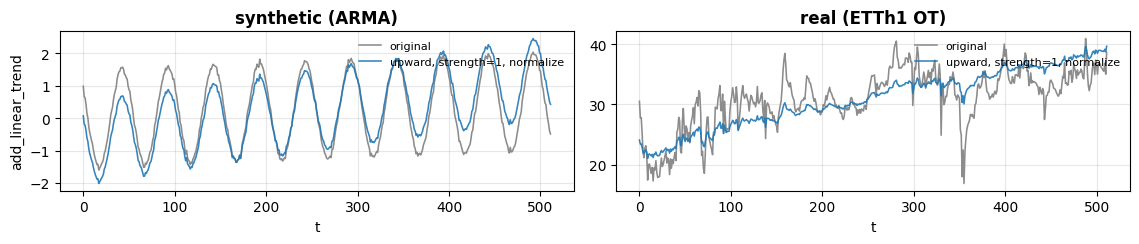

orig std / aug std  synth 1.073 1.073  real 4.813 4.813


In [2]:
aug_s = add_linear_trend(sine, trend_strength=1.0, direction="upward")
aug_r = add_linear_trend(real, trend_strength=1.0, direction="upward")
overlay_pair(
    [sine, real],
    [
        [("upward, strength=1, normalize", aug_s)],
        [("upward, strength=1, normalize", aug_r)],
    ],
    titles=["add_linear_trend"],
)
plt.show()
print(
    "orig std / aug std  synth",
    sine.std().round(3),
    aug_s.std().round(3),
    " real",
    real.std().round(3),
    aug_r.std().round(3),
)

## Parameter effect

`normalize=False` changes the amplitude. Larger `trend_strength` rotates the
series more. Downward vs upward just flips the slope.


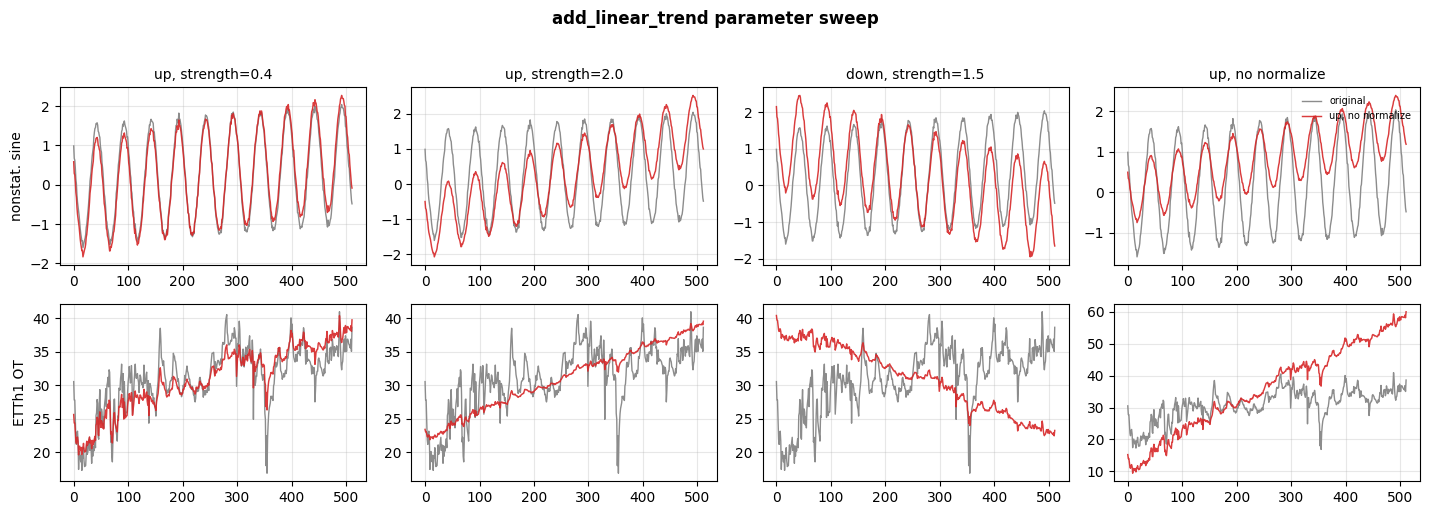

In [3]:
makers = [
    ("up, strength=0.4", lambda x: add_linear_trend(x, 0.4, "upward", True)),
    ("up, strength=2.0", lambda x: add_linear_trend(x, 2.0, "upward", True)),
    ("down, strength=1.5", lambda x: add_linear_trend(x, 1.5, "downward", True)),
    ("up, no normalize", lambda x: add_linear_trend(x, 1.5, "upward", False)),
]
sweep_grid(
    [sine, real],
    ["nonstat. sine", "ETTh1 OT"],
    makers,
    "add_linear_trend parameter sweep",
)
plt.show()